# 02 - Quality Analysis

## 1. Objectives

This notebook evaluates lead quality using the advertiser's ultimate success measure, `Closed`.

The analysis focuses on:

- Establishing the baseline Closed Rate.
- Understanding the distribution of lead outcomes.
- Examining how Closed Rate changes over time.
- Testing whether observed changes in lead quality are statistically significant.
- Comparing lead quality across relevant advertising, campaign, and lead segments.
- Identifying segments associated with meaningful differences in Closed Rate.

## 2. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

## 3. Load the Dataset

In [2]:
df = pd.read_excel("../data/raw/Analyst_case_study_dataset_1_.xls")
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset shape: 3,021 rows × 24 columns


In [3]:
df.head()

,LeadCreated,FirstName,Email,VendorLeadID,CallStatus,WidgetName,PublisherZoneName,PublisherCampaignName,AddressScore,PhoneScore,AdvertiserCampaignName,State,DebtLevel,IP Address,Partner,ReferralDomain,MarketingCampaign,AdGroup,Keyword,SearchQuery,ReferralURL,ReferralURL Parameters,LandingPageURL,Landing Page URL Parameters
0,2009-07-01 01:24:29.563,Dorinda,kanani@sandwichisles.net,FDF81FDA-A649-437B-B99C-FDDE74F7971B,NaN,w-302252-DebtReduction1-1DC-CreditSolutions,TopLeft-302252,DebtReductionInc,NaN,5.00,creditsolutions-branded-shortform,HI,30001-50000,NaN,google,www.google.com,Debt Holding Tank,Holding Tank - Debt,Debt specialists,debt specialists,http://www.google.com/search,sourceid=navclient&aq=1&oq=debt sp&ie=UTF-8&rl...,http://www.debtreductioninc.com/index8.html,utm_source=google&utm_medium=CPC&utm_content=H...
1,2009-04-13 15:27:35.990,Presetta,clerk2@ustconline.net,4190ACB7-5026-416C-B987-ED8AD427D5E6,NaN,w-300250-DebtReduction1-1DC-Head2,TopLeft-302252,DebtReductionInc,NaN,NaN,Debt Settlement1 Master,AL,90000-100000,NaN,AdKnowledge,NaN,Financial Services,Consolidate,NaN,NaN,NaN,NaN,http://www.debtreductioninc.com/index8.html,utm_source=AdKnowledge&utm_medium=CPC&utm_cont...
2,2009-04-21 07:22:59.000,Gina,wagoner_gina@yahoo.com,hFg80jf_R0CRN55hdhWILw,Unable to contact - Bad Contact Information,w-300250-DebtReduction1-1DC-Head2,TopLeft-302252,DebtReductionInc,NaN,NaN,Debt Settlement1 Master,NY,20001-30000,NaN,AdKnowledge,us.mc582.mail.yahoo.com,Financial Services,Consolidate,NaN,NaN,http://us.mc582.mail.yahoo.com/mc/showMessage,&fid=Inbox&sort=date&order=down&startMid=0&.ra...,http://www.debtreductioninc.com/index8.html,utm_source=AdKnowledge&utm_medium=CPC&utm_cont...
3,2009-08-03 19:39:02.000,Kari,usa4ley@yahoo.com,jB01QgYZxkWArI9jWxuufw,Contacted - Doesn't Qualify,w-302252-DebtReduction1-1DC-white,TopLeft-302252,DebtReductionInc,5.00,3.00,Debt Settlement1 Master,WA,20001-30000,NaN,Google,norwich.kijiji.com,DebtReductionInc,Lower Payments,NaN,NaN,http://norwich.kijiji.com/c-Cars-vehicles-Cars...,NaN,http://www.debtreductioninc.com/index12.html,utm_source=Google&utm_medium=cpc&utm_campaign=...
4,2009-04-13 10:18:37.490,Stephanie,sr1lambert@embarqmail.com,D5B32074-458E-40EC-B185-1FEF20AC626D,NaN,w-300250-DebtReduction1-1DC-BlueMeter,TopLeft-302252,DebtReductionInc,NaN,NaN,Debt Settlement1 Master,TX,More_than_100000,NaN,Google,NaN,DebtReductionInc,Debt Reduction,NaN,NaN,NaN,NaN,http://www.debtreductioninc.com/index8.html,utm_source=Google&utm_medium=cpc&utm_campaign=...


## 4. Baseline Lead Quality

The baseline Closed Rate provides the starting point for evaluating lead quality. Since `Closed` represents the advertiser's ultimate success measure, it is used as the primary KPI throughout the analysis.

In [4]:
total_leads = len(df)
closed_leads = df["CallStatus"].eq("Closed").sum()
closed_rate = closed_leads / total_leads

In [5]:
print(f"Total leads: {total_leads:,}")
print(f"Closed leads: {closed_leads:,}")
print(f"Closed Rate: {closed_rate:.2%}")

Total leads: 3,021
Closed leads: 245
Closed Rate: 8.11%


In [6]:
baseline = pd.DataFrame({"Metric": ["Total Leads", "Closed Leads", "Closed Rate"], "Value": [total_leads, closed_leads, closed_rate]})
baseline

,Metric,Value
0,Total Leads,"3,021.00"
1,Closed Leads,245.00
2,Closed Rate,0.08


The dataset contains 3,021 leads, of which 245 are marked as `Closed`, resulting in a baseline Closed Rate of 8.11%. This provides the reference point for the subsequent trend and segment analysis.

## 5. Lead Outcome Distribution

The distribution of observed `CallStatus` values provides context for the baseline Closed Rate and shows how leads progress through the available outcome stages. Missing statuses are kept separate because they do not represent an explicit outcome in the dataset.

In [7]:
outcome_summary = (df["CallStatus"].value_counts(dropna=False).rename_axis("CallStatus").reset_index(name="LeadCount"))
outcome_summary["LeadShare"] = (outcome_summary["LeadCount"] / len(df) * 100)
outcome_summary

,CallStatus,LeadCount,LeadShare
0,NaN,2140,70.84
1,Closed,245,8.11
2,Contacted - Doesn't Qualify,212,7.02
3,Unable to contact - Bad Contact Information,191,6.32
4,EP Confirmed,130,4.30
5,Contacted - Invalid Profile,85,2.81
6,EP Sent,16,0.53
7,EP Received,2,0.07


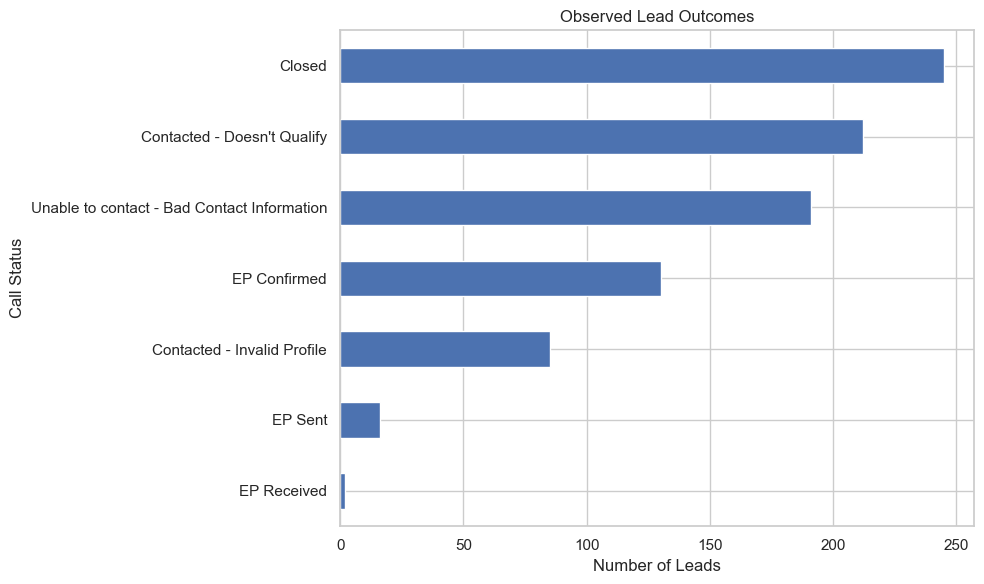

In [8]:
observed_outcomes = (df["CallStatus"].dropna().value_counts().sort_values(ascending=True))
plt.figure(figsize=(10, 6))
observed_outcomes.plot(kind="barh")
plt.title("Observed Lead Outcomes")
plt.xlabel("Number of Leads")
plt.ylabel("Call Status")
plt.tight_layout()
plt.show()

### Interpretation

Among leads with an observed outcome, `Closed` is the largest positive outcome category, while the remaining classified records represent intermediate progression stages or negative outcomes. The large number of missing `CallStatus` values remains an important limitation when interpreting the overall lead funnel.

In [9]:
df["IsClosed"] = df["CallStatus"].eq("Closed").astype(int)
df["IsClosed"].value_counts()

IsClosed
0    2776
1     245
Name: count, dtype: int64

## 6. Lead Quality Over Time

Examining Closed Rate over time helps determine whether lead quality has remained stable or changed during the period covered by the dataset. Monthly aggregation provides a consistent view of the trend while also accounting for differences in monthly lead volume.

In [10]:
monthly_quality = (df.assign(Month=df["LeadCreated"].dt.to_period("M").dt.to_timestamp()).groupby("Month")
                        .agg(TotalLeads=("IsClosed", "size"),ClosedLeads=("IsClosed", "sum")))
monthly_quality["ClosedRate"] = (monthly_quality["ClosedLeads"] / monthly_quality["TotalLeads"])
monthly_quality

,TotalLeads,ClosedLeads,ClosedRate
Month,,,
2009-04-01,518,56,0.11
2009-05-01,580,37,0.06
2009-06-01,609,63,0.10
2009-07-01,532,33,0.06
2009-08-01,438,41,0.09
2009-09-01,344,15,0.04


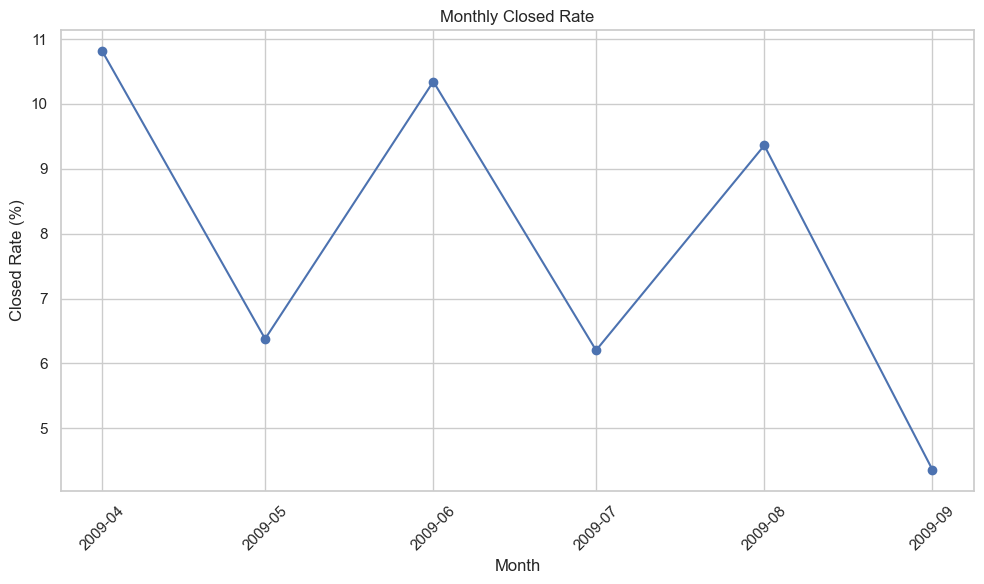

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(monthly_quality.index, monthly_quality["ClosedRate"] * 100, marker="o")
plt.title("Monthly Closed Rate")
plt.xlabel("Month")
plt.ylabel("Closed Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretation

The monthly Closed Rate shows how lead quality varied across the observation period. The pattern observed here will be tested statistically in the next step to determine whether any apparent trend represents a meaningful change rather than normal variation in the sample.

## 7. Statistical Significance of the Trend

The monthly Closed Rate provides a visual view of how lead quality changed over time, but differences between months can occur because of normal sampling variation.

To assess whether there is evidence of a systematic time trend, we test the relationship between time and monthly Closed Rate. The test provides a statistical basis for determining whether the observed movement is consistent with a meaningful trend.

In [12]:
monthly_quality = monthly_quality.reset_index()
monthly_quality["MonthNumber"] = np.arange(1, len(monthly_quality) + 1)
slope, intercept, r_value, p_value, std_err = stats.linregress(
    monthly_quality["MonthNumber"],
    monthly_quality["ClosedRate"]
)

print(f"Slope: {slope:.4f}")
print(f"R-squared: {r_value**2:.4f}")
print(f"P-value: {p_value:.4f}")

Slope: -0.0078
R-squared: 0.3138
P-value: 0.2476


In [13]:
print(f"Monthly Closed Rate changes by approximately " f"{slope * 100:.2f} percentage points per month.")

Monthly Closed Rate changes by approximately -0.78 percentage points per month.


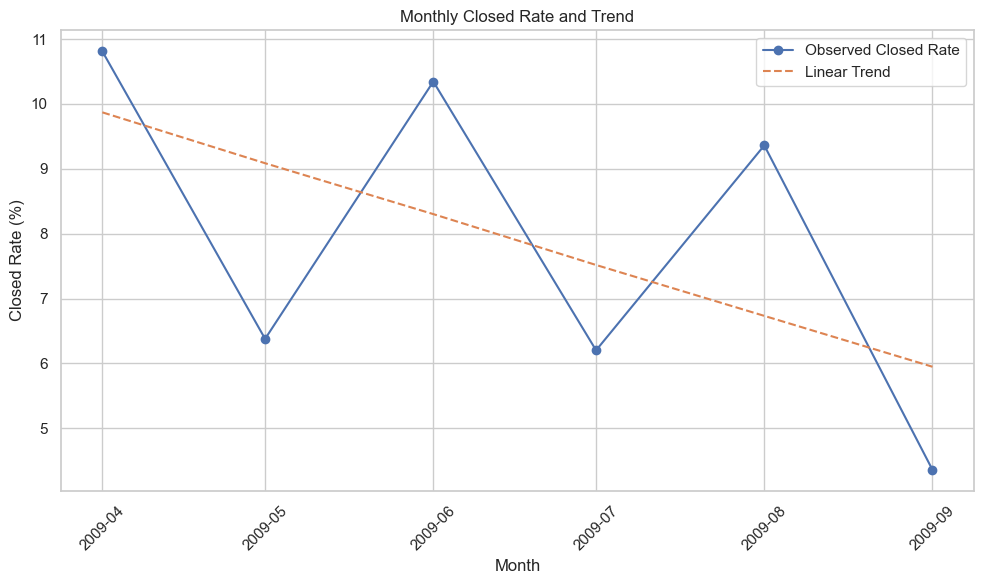

In [14]:
trend_values = intercept + slope * monthly_quality["MonthNumber"]
plt.figure(figsize=(10, 6))
plt.plot(monthly_quality["Month"], monthly_quality["ClosedRate"] * 100, marker="o", label="Observed Closed Rate")
plt.plot(monthly_quality["Month"], trend_values * 100, linestyle="--", label="Linear Trend")
plt.title("Monthly Closed Rate and Trend")
plt.xlabel("Month")
plt.ylabel("Closed Rate (%)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation

- The statistical test provides evidence on whether the observed monthly movement represents a systematic trend. The p-value is compared with a 0.05 significance threshold: a p-value below 0.05 indicates statistically significant evidence of a linear relationship between time and Closed Rate, while a higher p-value does not provide sufficient evidence of a statistically significant trend.
- The direction and magnitude of the estimated slope indicate whether Closed Rate is increasing or decreasing over the observed period.

## 8. Lead Quality by Widget

Different `WidgetName` values represent different form and creative configurations shown to users. Comparing Closed Rate across widgets helps determine whether the way the lead form is presented is associated with differences in lead quality.

In [15]:
widget_quality = (df.groupby("WidgetName").agg(TotalLeads=("IsClosed", "size"), ClosedLeads=("IsClosed", "sum")))
widget_quality["ClosedRate"] = (widget_quality["ClosedLeads"] / widget_quality["TotalLeads"])
widget_quality = (widget_quality.sort_values("ClosedRate", ascending=False))
widget_quality

,TotalLeads,ClosedLeads,ClosedRate
WidgetName,,,
w-300250-DebtReduction1-1DC-white,6,1,0.17
w-300250-DebtReduction1-1DC-CreditSolutions,77,12,0.16
w-300250-DebtReduction1-1DC-BlueMeter,92,13,0.14
w-300250-DebtReduction1-1DC-Head2,89,11,0.12
w-300250-DebtReduction1-1DC,348,34,0.10
w-302252-DebtReduction1-1DC,272,23,0.08
w-300250-DebtReduction1-2DC-CreditSolutions,75,6,0.08
w-302252-DebtReduction1-1DC-yellowarrow-dark,135,10,0.07
w-302252-DebtReduction1-1DC-CreditSolutions,1054,76,0.07


In [16]:
widget_quality["ShareOfLeads"] = (widget_quality["TotalLeads"] / len(df) * 100)
widget_quality

,TotalLeads,ClosedLeads,ClosedRate,ShareOfLeads
WidgetName,,,,
w-300250-DebtReduction1-1DC-white,6,1,0.17,0.20
w-300250-DebtReduction1-1DC-CreditSolutions,77,12,0.16,2.55
w-300250-DebtReduction1-1DC-BlueMeter,92,13,0.14,3.05
w-300250-DebtReduction1-1DC-Head2,89,11,0.12,2.95
w-300250-DebtReduction1-1DC,348,34,0.10,11.52
w-302252-DebtReduction1-1DC,272,23,0.08,9.00
w-300250-DebtReduction1-2DC-CreditSolutions,75,6,0.08,2.48
w-302252-DebtReduction1-1DC-yellowarrow-dark,135,10,0.07,4.47
w-302252-DebtReduction1-1DC-CreditSolutions,1054,76,0.07,34.89


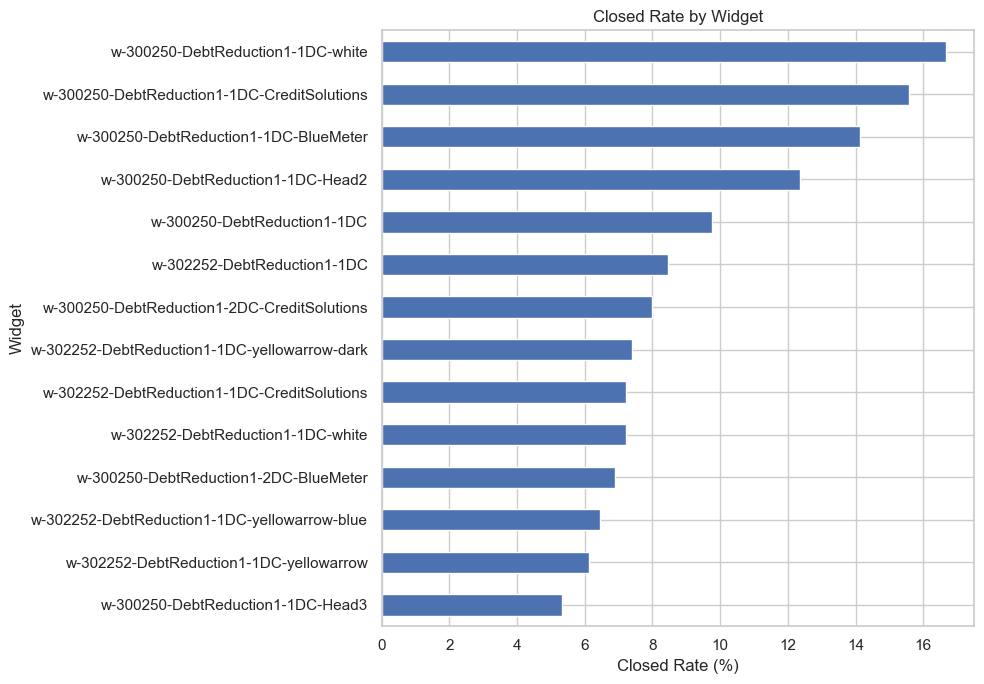

In [17]:
plt.figure(figsize=(10, 7))
widget_quality["ClosedRate"].sort_values().mul(100).plot(kind="barh")
plt.title("Closed Rate by Widget")
plt.xlabel("Closed Rate (%)")
plt.ylabel("Widget")
plt.tight_layout()
plt.show()

### Interpretation

Closed Rate varies across the observed widget configurations, indicating that lead quality is not uniform across all form variants.

However, differences in Closed Rate should be considered alongside lead volume. Widgets with substantially fewer leads can show larger rate fluctuations simply because their underlying sample is smaller. The segment results therefore provide evidence for further investigation rather than establishing that the widget itself causes higher or lower lead quality.

## 9. Lead Quality by Publisher Placement

`PublisherZoneName` describes where the advertisement was displayed on the publisher's page. Comparing Closed Rate across placements helps determine whether ad position is associated with differences in lead quality.

In [18]:
zone_quality = (df.groupby("PublisherZoneName").agg(TotalLeads=("IsClosed", "size"),ClosedLeads=("IsClosed", "sum")))
zone_quality["ClosedRate"] = (zone_quality["ClosedLeads"] / zone_quality["TotalLeads"])
zone_quality["ShareOfLeads"] = (zone_quality["TotalLeads"] / len(df) * 100)
zone_quality.sort_values("ClosedRate", ascending=False)

,TotalLeads,ClosedLeads,ClosedRate,ShareOfLeads
PublisherZoneName,,,,
Top Right-300x250,271,26,0.10,8.97
TopLeft-302252,2750,219,0.08,91.03


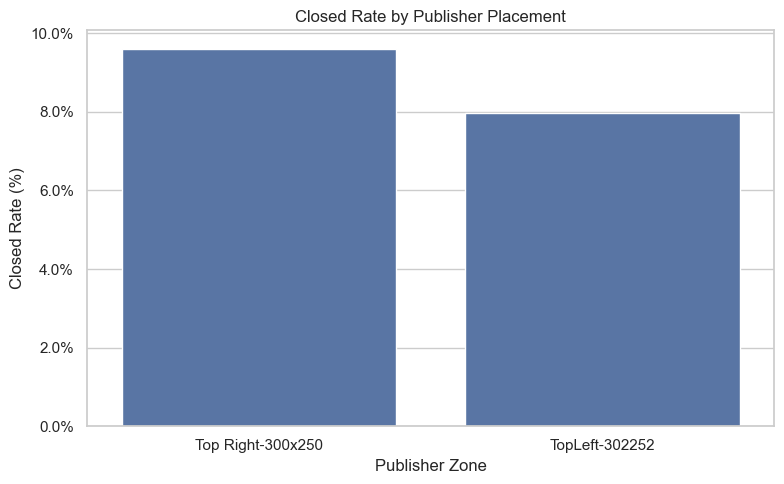

In [19]:
plt.figure(figsize=(8, 5))
sns.barplot(data=zone_quality.reset_index(), x="PublisherZoneName", y="ClosedRate")
plt.title("Closed Rate by Publisher Placement")
plt.xlabel("Publisher Zone")
plt.ylabel("Closed Rate (%)")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
plt.tight_layout()
plt.show()

### Interpretation

The comparison shows whether the two available publisher placements have different observed Closed Rates. Because there are only two placements, the comparison is straightforward, but lead volume should still be considered when interpreting the difference.

## 10. Lead Quality by Publisher Campaign

`PublisherCampaignName` distinguishes the publisher's online form traffic from leads entered through the call-center campaign. Comparing the two groups helps determine whether the acquisition method is associated with different levels of lead quality.

In [20]:
publisher_campaign_quality = (df.groupby("PublisherCampaignName").agg(TotalLeads=("IsClosed", "size"), ClosedLeads=("IsClosed", "sum")))
publisher_campaign_quality["ClosedRate"] = (publisher_campaign_quality["ClosedLeads"] / publisher_campaign_quality["TotalLeads"])
publisher_campaign_quality["ShareOfLeads"] = (publisher_campaign_quality["TotalLeads"] / len(df) * 100)
publisher_campaign_quality.sort_values("ClosedRate", ascending=False)

,TotalLeads,ClosedLeads,ClosedRate,ShareOfLeads
PublisherCampaignName,,,,
DebtReductionCallCenter,271,26,0.10,8.97
DebtReductionInc,2750,219,0.08,91.03


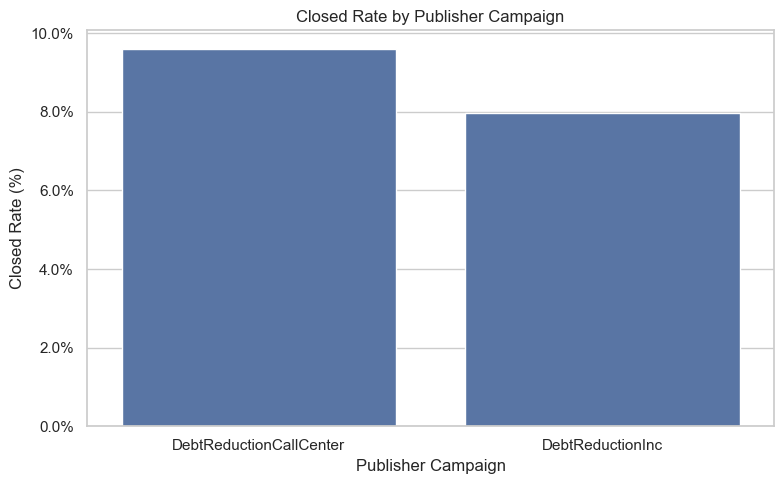

In [21]:
plt.figure(figsize=(8, 5))
sns.barplot(data=publisher_campaign_quality.reset_index(), x="PublisherCampaignName", y="ClosedRate")
plt.title("Closed Rate by Publisher Campaign")
plt.xlabel("Publisher Campaign")
plt.ylabel("Closed Rate (%)")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
plt.tight_layout()
plt.show()

### Interpretation

The comparison indicates whether the two publisher campaign types generate different observed levels of lead quality. Differences should be considered together with the number of leads represented by each campaign before drawing conclusions about the underlying acquisition channel.

## 11. Lead Quality by Advertiser Campaign

`AdvertiserCampaignName` distinguishes between the branded and generic advertiser campaign experiences. Comparing Closed Rate across these campaign variants helps assess whether advertiser branding is associated with differences in lead quality.

In [22]:
advertiser_campaign_quality = (df.groupby("AdvertiserCampaignName").agg(TotalLeads=("IsClosed", "size"), ClosedLeads=("IsClosed", "sum")))
advertiser_campaign_quality["ClosedRate"] = (advertiser_campaign_quality["ClosedLeads"] / advertiser_campaign_quality["TotalLeads"])
advertiser_campaign_quality["ShareOfLeads"] = (advertiser_campaign_quality["TotalLeads"] / len(df) * 100)
advertiser_campaign_quality.sort_values("ClosedRate", ascending=False)

,TotalLeads,ClosedLeads,ClosedRate,ShareOfLeads
AdvertiserCampaignName,,,,
Debt Settlement1 Master,1815,151,0.08,60.08
creditsolutions-branded-shortform,1206,94,0.08,39.92


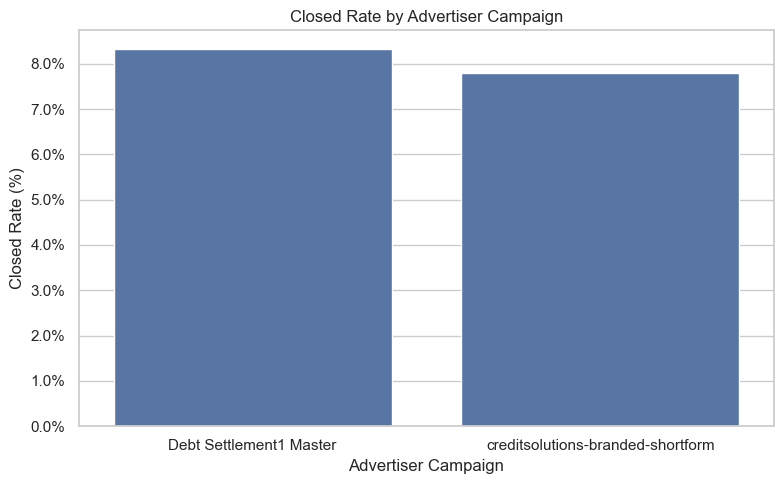

In [23]:
plt.figure(figsize=(8, 5))
sns.barplot(data=advertiser_campaign_quality.reset_index(), x="AdvertiserCampaignName", y="ClosedRate")
plt.title("Closed Rate by Advertiser Campaign")
plt.xlabel("Advertiser Campaign")
plt.ylabel("Closed Rate (%)")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
plt.tight_layout()
plt.show()

### Interpretation

The two advertiser campaign variants show similar Closed Rates despite representing substantial lead volumes. `Debt Settlement1 Master` has a Closed Rate of approximately 8.3%, compared with approximately 7.8% for `creditsolutions-branded-shortform`, a difference of about 0.5 percentage points.

This suggests that advertiser branding is not associated with a large difference in observed lead quality within this dataset. The comparison is descriptive and does not establish that the campaign experience itself causes the difference.

## 12. Lead Quality by Partner

`Partner` identifies the advertising source responsible for generating the traffic. Comparing Closed Rate across partners can help identify whether lead quality differs by acquisition source.

In [24]:
partner_quality = (df.groupby("Partner").agg(TotalLeads=("IsClosed", "size"),ClosedLeads=("IsClosed", "sum")))
partner_quality["ClosedRate"] = (partner_quality["ClosedLeads"] / partner_quality["TotalLeads"])
partner_quality["ShareOfLeads"] = (partner_quality["TotalLeads"] / len(df) * 100)
partner_quality.sort_values("ClosedRate", ascending=False)
partner_quality.sort_values("TotalLeads", ascending=False)

,TotalLeads,ClosedLeads,ClosedRate,ShareOfLeads
Partner,,,,
google,979,97,0.10,32.41
yahoo,958,74,0.08,31.71
Google,639,26,0.04,21.15
Call_Center,271,26,0.10,8.97
AdKnowledge,171,21,0.12,5.66
Advertise.com,3,1,0.33,0.10


In [25]:
print(f"Number of partners: {df['Partner'].nunique()}")

Number of partners: 6


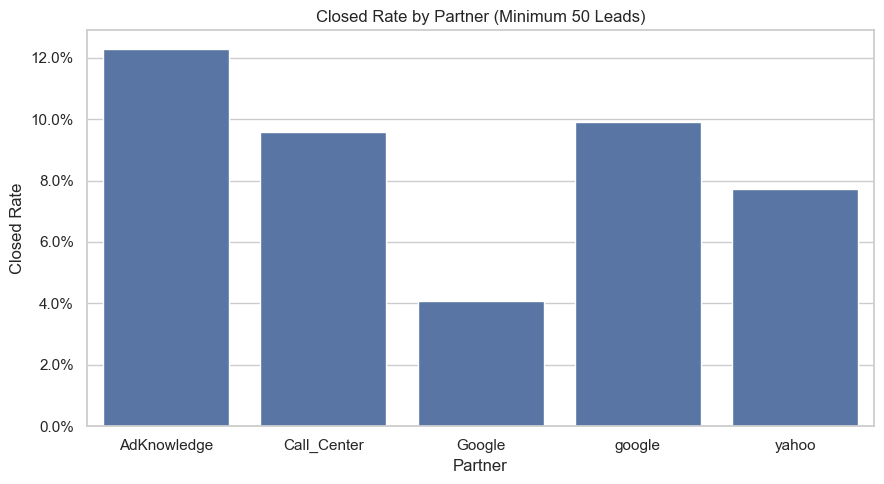

In [26]:
partner_quality_chart = partner_quality[partner_quality["TotalLeads"] >= 50]
plt.figure(figsize=(9, 5))
sns.barplot(data=partner_quality_chart.reset_index(), x="Partner", y="ClosedRate")
plt.title("Closed Rate by Partner (Minimum 50 Leads)")
plt.xlabel("Partner")
plt.ylabel("Closed Rate")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
plt.tight_layout()
plt.show()

### Interpretation

Closed Rate varies across the higher-volume partners, indicating that acquisition source may be associated with differences in observed lead quality. AdKnowledge has the highest Closed Rate among partners with at least 50 leads, while the two Google-labelled categories show different observed rates.

The `Advertise.com` rate should not be interpreted as a meaningful high-quality segment because it is based on only three leads. The separate `google` and `Google` categories also indicate a naming inconsistency that should be considered before making optimization decisions.

## 13. Lead Quality by Debt Level

`DebtLevel` represents the reported debt level of the lead. Comparing Closed Rate across debt levels helps determine whether lead quality varies systematically with the underlying characteristics of the lead.

In [27]:
df["DebtLevel"].value_counts(dropna=False).sort_index()

DebtLevel
10001-15000         291
15001-20000         408
20001-30000         456
30001-50000         496
50001-70000         245
70001-90000         131
7500-10000          442
7500-15000          271
90000-100000         90
More_than_100000    191
Name: count, dtype: int64

In [28]:
debt_quality = (df.groupby("DebtLevel").agg(TotalLeads=("IsClosed", "size"),ClosedLeads=("IsClosed", "sum")))
debt_quality["ClosedRate"] = (debt_quality["ClosedLeads"] / debt_quality["TotalLeads"])
debt_quality["ShareOfLeads"] = (debt_quality["TotalLeads"] / len(df) * 100)
debt_quality

,TotalLeads,ClosedLeads,ClosedRate,ShareOfLeads
DebtLevel,,,,
10001-15000,291,34,0.12,9.63
15001-20000,408,35,0.09,13.51
20001-30000,456,40,0.09,15.09
30001-50000,496,39,0.08,16.42
50001-70000,245,22,0.09,8.11
70001-90000,131,18,0.14,4.34
7500-10000,442,22,0.05,14.63
7500-15000,271,19,0.07,8.97
90000-100000,90,9,0.10,2.98


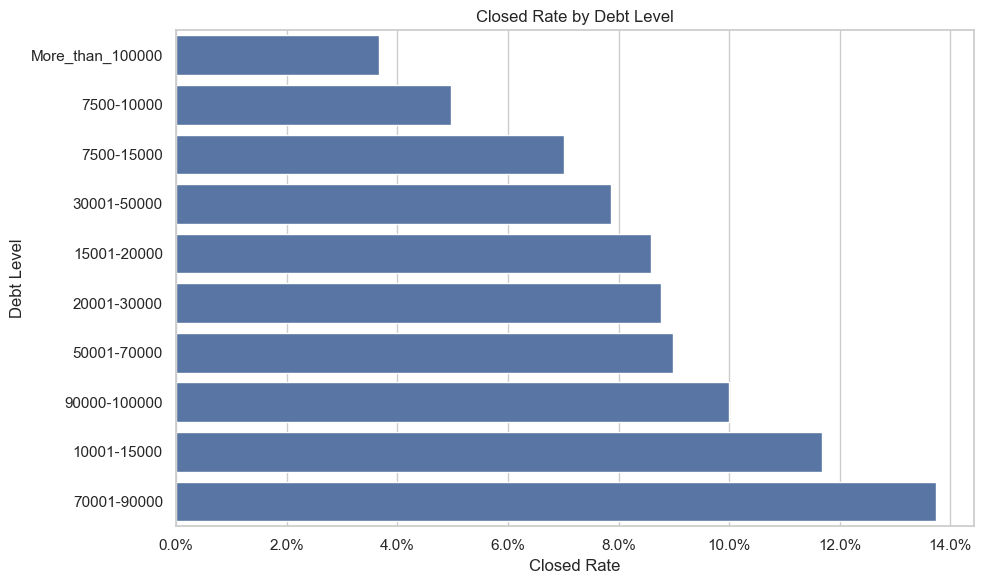

In [29]:
plt.figure(figsize=(10, 6))
debt_plot = debt_quality.sort_values("ClosedRate")
sns.barplot(data=debt_plot.reset_index(), x="ClosedRate", y="DebtLevel")
plt.title("Closed Rate by Debt Level")
plt.xlabel("Closed Rate")
plt.ylabel("Debt Level")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1%}"))
plt.tight_layout()
plt.show()

### Interpretation

Closed Rate varies across debt-level segments, but the relationship is not strictly monotonic. For example, the `70001-90000` segment has an observed Closed Rate of approximately 13.7%, while `More_than_100000` is approximately 3.7%.

The lower `7500-10000` segment also has a relatively low Closed Rate of approximately 5.0%. These differences suggest that debt level may be associated with lead quality, although the results should be interpreted together with lead volume and other acquisition characteristics.

## 14. Lead Quality by State

Geographic differences can provide additional context on lead quality. State-level Closed Rates are examined together with lead volume so that small segments are not overinterpreted.

In [30]:
state_quality = (df.groupby("State").agg(TotalLeads=("IsClosed", "size"), ClosedLeads=("IsClosed", "sum")))
state_quality["ClosedRate"] = (state_quality["ClosedLeads"] / state_quality["TotalLeads"])
state_quality["ShareOfLeads"] = (state_quality["TotalLeads"] / len(df) * 100)
state_quality.sort_values("TotalLeads", ascending=False)

,TotalLeads,ClosedLeads,ClosedRate,ShareOfLeads
State,,,,
CA,463,44,0.10,15.33
TX,325,28,0.09,10.76
NY,283,17,0.06,9.37
FL,261,18,0.07,8.64
IL,186,14,0.08,6.16
MI,145,11,0.08,4.80
VA,145,12,0.08,4.80
CO,105,7,0.07,3.48
MD,98,6,0.06,3.24


In [31]:
print(f"Number of states: {df['State'].nunique()}")

Number of states: 32


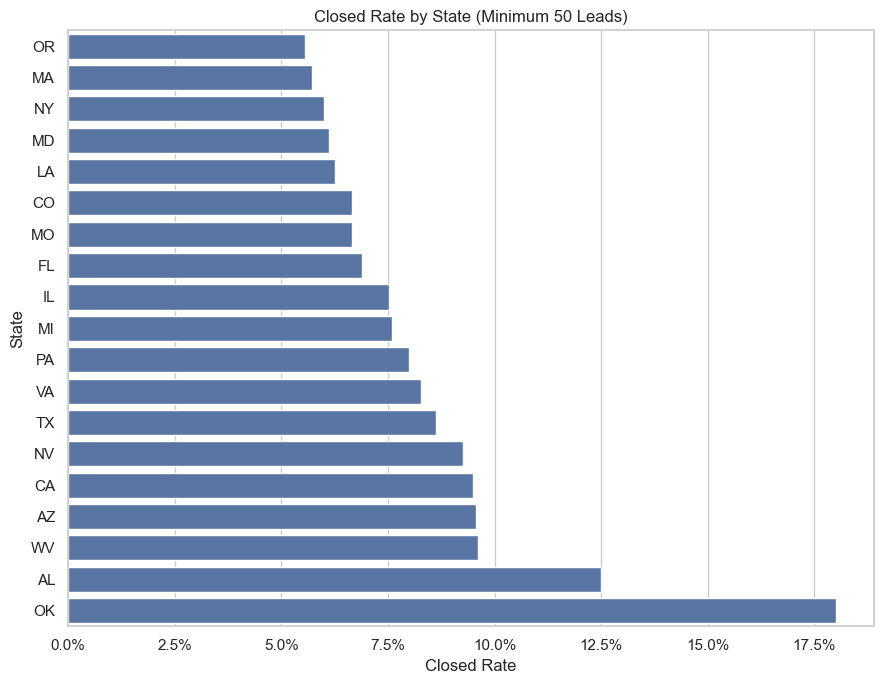

In [32]:
state_quality_chart = state_quality[state_quality["TotalLeads"] >= 50].sort_values("ClosedRate")
plt.figure(figsize=(9, 7))
sns.barplot(data=state_quality_chart.reset_index(), x="ClosedRate", y="State")
plt.title("Closed Rate by State (Minimum 50 Leads)")
plt.xlabel("Closed Rate")
plt.ylabel("State")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1%}"))
plt.tight_layout()
plt.show()

### Interpretation

Closed Rate varies across states, with some higher-volume states showing noticeably different observed rates. For example, California has a Closed Rate of approximately 9.5%, while New York is approximately 6.0%.

Some smaller states show higher rates, but their lower lead volumes make those estimates less stable. State therefore provides useful segmentation context, but the observed differences should not be interpreted independently of acquisition source, campaign, or other lead characteristics.

## Final Conclusion

This notebook evaluates lead quality using `Closed` as the advertiser's ultimate success measure. Across the **3,021 leads**, there are **245 Closed leads**, producing an overall Closed Rate of **8.11%**. This provides the baseline against which time trends and segment-level differences can be evaluated.

### Lead Quality Over Time

Monthly Closed Rate varies considerably during the observation period:

- **April:** approximately 10.8%
- **May:** approximately 6.4%
- **June:** approximately 10.3%
- **July:** approximately 6.2%
- **August:** approximately 9.4%
- **September:** approximately 4.4%

The observed rates therefore move downward toward the end of the period, with September recording the lowest monthly Closed Rate.

However, the statistical trend test produces a slope of approximately **-0.78 percentage points per month** with a **p-value of 0.248**. Since the p-value is above the 5% significance threshold, the observed downward movement is **not statistically significant**.

Therefore, the data shows an observed decline in monthly Closed Rate, but there is insufficient statistical evidence to conclude that lead quality experienced a systematic decline over time.

### Lead Quality by Widget

Closed Rate differs across the available widget configurations. Some widgets show substantially higher observed rates than others, indicating that lead quality is not uniform across all form and creative configurations.

However, lead volume varies considerably between widgets. Small-volume widgets can produce relatively high or low Closed Rates from only a small number of Closed leads, making those rates less stable.

The widget results should therefore be treated as potential optimization signals rather than evidence that a particular widget directly causes higher lead quality.

### Lead Quality by Publisher Placement and Campaign

The two publisher placements have different observed Closed Rates:

- `Top Right-300x250`: approximately **9.6%**
- `TopLeft-302252`: approximately **8.0%**

The corresponding publisher campaign comparison produces the same underlying split:

- `DebtReductionCallCenter`: approximately **9.6%**
- `DebtReductionInc`: approximately **8.0%**

An important data-structure finding is that `PublisherZoneName` and `PublisherCampaignName` are closely aligned in this dataset, with both dividing the records into the same **271-lead and 2,750-lead groups**.

Consequently, these should not be interpreted as two independent drivers of lead quality. The observed difference represents the same underlying group of leads viewed through two related variables.

### Lead Quality by Advertiser Campaign

The two advertiser campaign experiences show very similar Closed Rates:

- `Debt Settlement1 Master`: approximately **8.3%**
- `creditsolutions-branded-shortform`: approximately **7.8%**

Both groups contain substantial lead volumes, and the difference is relatively small at approximately **0.5 percentage points**.

This suggests that advertiser branding is not associated with a large difference in observed lead quality within this dataset. The analysis is descriptive and does not establish a causal effect of the campaign experience.

### Lead Quality by Partner

Partner-level results show more noticeable variation in observed Closed Rate among the higher-volume acquisition sources.

`AdKnowledge` records an observed Closed Rate of approximately **12.3%**, while `google` is approximately **9.9%**, `Call_Center` approximately **9.6%**, `yahoo` approximately **7.7%**, and `Google` approximately **4.1%**.

The `Advertise.com` result of approximately 33.3% should not be interpreted as evidence of substantially higher lead quality because it is based on only **3 leads**.

There is also a naming inconsistency between `google` and `Google`, which appear as separate categories. This should be investigated before making acquisition-level optimization decisions because the distinction may represent different sources or inconsistent naming.

Overall, partner-level results suggest that acquisition source may be an important dimension for further investigation.

### Lead Quality by Debt Level

Closed Rate varies across debt-level segments, but the relationship is not strictly increasing or decreasing.

For example, the `70001-90000` segment has a Closed Rate of approximately **13.7%**, while `More_than_100000` is approximately **3.7%**. The `7500-10000` segment also has a relatively low observed rate of approximately **5.0%**.

This suggests that debt level may contain useful information about lead quality, but the results do not support a simple conclusion that higher debt consistently produces either better or worse leads.

### Lead Quality by State

There is also geographic variation in observed Closed Rate. Among the larger state segments, California records approximately **9.5%**, Texas approximately **8.6%**, New York approximately **6.0%**, and Florida approximately **6.9%**.

Some smaller states show substantially higher or lower observed rates, but their limited lead volumes make these estimates less stable.

State therefore provides useful segmentation information, but geographic differences should be considered alongside acquisition source, campaign, debt level, and other lead characteristics rather than being treated as independent explanations for lead quality.

### Overall Conclusion

The analysis identifies several dimensions associated with differences in observed lead quality. **Partner, widget configuration, debt level, and geography** show meaningful variation in Closed Rate, while the two advertiser campaign experiences show relatively similar performance.

The strongest caution applies to interpretation of these segment differences. The analysis is observational and does not establish causality. Small-volume segments can also produce unstable rates, and several fields contain substantial missing information.

The time-series analysis provides an additional important finding: although the observed monthly Closed Rate moves downward during the period, the decline is **not statistically significant** at the 5% level. Therefore, the data does not provide sufficient evidence of a systematic deterioration in lead quality over time.

Overall, the results suggest that lead quality is not uniform across all acquisition and lead characteristics. The next step is to translate these observed differences into an **economic opportunity analysis**, particularly around the advertiser's proposed increase from **$30 to $33 CPL** and the requirement for a **20% relative improvement in Closed Rate from approximately 8.0% to 9.6%**.